# BookSmart: Predicting Optimal Booking Timing for Intercity Bus Travel Using Web-Scraped Fare Data

**Student Name:** Deepak S
**Register Number:** CB.SC.U4CSE23267
**Class/Section:** CSE-C
**Business Domain:** Transportation - Intercity Bus Travel and Online Ticketing

---

## 1. Problem Statement and Objectives

Intercity bus operators in India price seats **dynamically**: the fare quoted for the same route,
operator and bus type changes with **when** the ticket is booked. Travellers, corporate travel desks and
bulk bookers decide booking timing on intuition, which leads to avoidable overpayment on some journeys
and missed low-fare windows on others.

**Objectives**

1. Identify the factors that drive quoted intercity bus fares (days-to-departure, seat availability,
   operator, bus type, departure slot, day-of-week, festival periods).
2. Build a regression model that predicts the expected fare of a listing.
3. Build a classification model that labels a quoted fare **Book Now** (cheaper than what the same
   service charges close to departure) or **Wait**.
4. Quantify how fare escalation differs across operators and corridors.

## 2. Setup

In [1]:
import warnings, re, json, time, math
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 170
SEED = 42

RAW_CSV   = Path("data/raw/bus_fares_raw_2026-09-25.csv")
CLEAN_CSV = Path("data/cleaned/bus_fares_clean.csv")
Path("assets/figures").mkdir(parents=True, exist_ok=True)

# Corridors and redBus city IDs used by the public search-results endpoint
ROUTES = {
    ("Bengaluru", "Chennai"):    (122, 123),
    ("Bengaluru", "Hyderabad"):  (122, 124),
    ("Chennai",   "Coimbatore"): (123, 141),
    ("Bengaluru", "Coimbatore"): (122, 141),
    ("Hyderabad", "Vijayawada"): (124, 134),
    ("Mumbai",    "Pune"):       (462, 130),
    ("Chennai",   "Madurai"):    (123, 126),
    ("Delhi",     "Jaipur"):     (733, 807),
}
# Departure dates sampled at these offsets from the scrape date (booking window, days)
HORIZON_DAYS = [1, 2, 3, 4, 5, 6, 7, 10, 14, 21, 30, 45, 60]

## 3. Data Collection (Web Scraping)

**Source:** [redBus](https://www.redbus.in) - India's largest online bus-ticketing platform. Its public
search-results pages (e.g. `redbus.in/bus-tickets/bangalore-to-chennai`) are viewable without login.

**Procedure**

1. For each of **8 corridors** and **13 departure dates** (1, 2, 3, 4, 5, 6, 7, 10, 14, 21, 30, 45 and 60
   days after the scrape date, 25 Sep 2026), the search-results page was requested.
2. The page loads its listings from a JSON endpoint (`/rpw/api/searchResults`) that the site's own
   front-end calls; the same endpoint was queried, paging through results 100 at a time, so every
   listed bus was captured (not only the first screen).
3. Script requests (curl/Python) could not reach the site from the analysis environment, so collection ran
   inside a regular browser session on the site (full script: `scraper/redbus_collector.js`), with a
   1.2-1.5 s delay between requests - 104 search pages in total.
4. Each record = one bus service listed for one route and departure date. Fields kept: operator, bus
   type, AC/sleeper flags, departure/arrival time, journey duration, rating and review count, seats
   available and total seats, minimum and maximum seat fare, direct/via flag and the operator's
   service code.

**Ethics:** only publicly displayed listing information was collected; no login, no booking, no personal
or passenger data. The service code identifies a bus schedule, not a person.

In [2]:
# The browser-console collector that produced data/raw/ (kept for reproducibility).
# Paste into the DevTools console on any redbus.in page, then download window.__rows as CSV.
COLLECTOR_JS = r"""
const R=[['Bengaluru','Chennai',122,123],['Bengaluru','Hyderabad',122,124],
 ['Chennai','Coimbatore',123,141],['Bengaluru','Coimbatore',122,141],
 ['Hyderabad','Vijayawada',124,134],['Mumbai','Pune',462,130],
 ['Chennai','Madurai',123,126],['Delhi','Jaipur',733,807]];
const OFF=[1,2,3,4,5,6,7,10,14,21,30,45,60];
// for each route x offset: POST /rpw/api/searchResults?fromCity=..&toCity=..&DOJ=dd-Mon-yyyy
//   &limit=100&offset=k ... ; page until fewer than 100 results; sleep 1.2-1.5 s between calls;
// keep: doj, travelsName, busType, isAc, isSleeper, departureTime, arrivalTime,
//   journeyDurationMin, totalRatings, numberOfReviews, availableSeats, totalSeats,
//   min(fareList), max(fareList), viaRt, serviceId
"""

def scrape_redbus(session, from_id, to_id, doj, page_size=100):
    """Python equivalent of the browser collector (not the path used for data/raw/)."""
    rows, offset = [], 0
    while True:
        url = ("https://www.redbus.in/rpw/api/searchResults"
               f"?fromCity={from_id}&toCity={to_id}&DOJ={doj:%d-%b-%Y}"
               f"&limit={page_size}&offset={offset}&meta=true&groupId=0&sectionId=0"
               "&sort=0&sortOrder=0&from=initialLoad&getUuid=true&bT=1&isFilterApplied=false")
        r = session.post(url, json={}, timeout=20)
        inv = r.json()["data"]["inventories"]
        rows += inv
        if len(inv) < page_size:
            return rows
        offset += page_size
        time.sleep(1.2)

raw = pd.read_csv(RAW_CSV)
print(f"Raw records: {len(raw):,}   columns: {raw.shape[1]}")
print("Scrape date:", raw['scrape_date'].unique())
raw.head()

Raw records: 32,372   columns: 19
Scrape date: <StringArray>
['2026-09-25']
Length: 1, dtype: str


,scrape_date,source,destination,departure_date,operator,bus_type,is_ac,is_sleeper,departure_time,arrival_time,duration_min,rating,num_reviews,seats_available,total_seats,fare_min,fare_max,via,service_id
0,2026-09-25,Bengaluru,Chennai,2026-09-26,V Bus Holidays,Bharat Benz A/C Sleeper (2+1),1,1,22:30,05:20,410,4.9,1400.0,17,37.0,1470.0,2070.0,Direct Bus,SCH4B8C35K
1,2026-09-25,Bengaluru,Chennai,2026-09-26,SRI SAI TRAVELS,A/C Seater / Sleeper (2+1),1,1,23:10,06:20,430,4.9,1200.0,36,48.0,555.0,1400.0,Direct Bus,33-0815PM-33
2,2026-09-25,Bengaluru,Chennai,2026-09-26,Jabbar Travels,Volvo 9600 Multi-Axle A/C Sleeper (2+1),1,1,23:15,05:45,390,4.8,1443.0,25,41.0,858.0,1460.0,Direct Bus,241
3,2026-09-25,Bengaluru,Chennai,2026-09-26,ANT KING,Volvo B11R Multi-Axle A/C Sleeper (2+1),1,1,23:45,06:00,375,4.5,970.0,24,42.0,910.0,1460.0,Direct Bus,SCH378C28D
4,2026-09-25,Bengaluru,Chennai,2026-09-26,MMK Travels,Bharat Benz A/C Sleeper (2+1),1,1,22:40,06:40,480,4.8,1367.0,11,37.0,1300.0,1930.0,Direct Bus,SCH398815E


In [3]:
print("Listings per corridor:")
print(raw.groupby(['source','destination']).size().to_string())
print("\nListings per departure date:")
print(raw.groupby('departure_date').size().to_string())

Listings per corridor:
source     destination
Bengaluru  Chennai        2716
           Coimbatore     2759
           Hyderabad      3380
Chennai    Coimbatore     2270
           Madurai        4608
Delhi      Jaipur         2881
Hyderabad  Vijayawada     6929
Mumbai     Pune           6829

Listings per departure date:
departure_date
2026-09-26    2794
2026-09-27    2905
2026-09-28    2966
2026-09-29    2939
2026-09-30    2939
2026-10-01    3025
2026-10-02    3035
2026-10-05    3021
2026-10-09    3036
2026-10-16    2631
2026-10-25    1629
2026-11-09     951
2026-11-24     501


## 4. Data Preparation

Steps:

1. **Type fixes** - fares, seats, ratings and review counts to numbers; duration to hours.
2. **Invalid rows** - drop listings with no fare (sold-out or not bookable) or zero seats capacity.
3. **Duplicates** - the endpoint can repeat a service across pages; keep one row per
   (route, departure date, service code).
4. **Missing ratings** - new services show rating 0 / blank; treated as missing and imputed with the
   operator's median, then the global median.
5. **Derived features** - `days_to_departure`, travel day-of-week, weekend flag (Fri-Sun), departure
   time slot, occupancy rate (1 - seats available / total seats), bus class (AC/Non-AC x
   Sleeper/Seater), government vs private operator, and a **festival flag** for departures falling in
   the Gandhi Jayanti long weekend (1-4 Oct), the Dussehra/Ayudha Puja week (16-21 Oct) and the
   Diwali/Chhath period (5-16 Nov 2026).
6. **Outliers** - fares capped to the 1st-99th percentile within each corridor (removes glitches such as
   placeholder fares while keeping genuine premium buses).
7. **Anonymisation** - no personal data exists in the source; the operator service code is replaced by an
   integer ID in the cleaned file.

In [4]:
df = raw.copy()
n0 = len(df)

num_cols = ["fare_min","fare_max","seats_available","total_seats","rating","num_reviews","duration_min"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 2. invalid rows
df = df[(df["fare_min"] > 0) & (df["total_seats"] > 0)]
n_invalid = n0 - len(df)

# 3. duplicates - a service is identified by operator + operator service code + departure time
df["svc"] = (df["operator"].astype(str) + "|" + df["service_id"].astype(str) + "|"
             + df["departure_time"].astype(str) + "|" + df["source"] + "|" + df["destination"])
before = len(df)
df = df.drop_duplicates(subset=["departure_date","svc"])
n_dup = before - len(df)

# 4. ratings: 0 means 'no rating yet'
df.loc[df["rating"] <= 0, "rating"] = np.nan
n_missing_rating = df["rating"].isna().sum()
df["rating"] = df.groupby("operator")["rating"].transform(lambda s: s.fillna(s.median()))
df["rating"] = df["rating"].fillna(df["rating"].median())
df["num_reviews"] = df["num_reviews"].fillna(0)

# 5. derived features
df["fare"] = df["fare_min"]                                   # starting fare shown to the buyer
df["departure_date"] = pd.to_datetime(df["departure_date"])
df["scrape_date"]    = pd.to_datetime(df["scrape_date"])
df["days_to_departure"] = (df["departure_date"] - df["scrape_date"]).dt.days
df["day_of_week"] = df["departure_date"].dt.day_name()
df["is_weekend_dep"] = df["departure_date"].dt.weekday.isin([4, 5, 6]).astype(int)
df["duration_hrs"] = df["duration_min"] / 60
df["occupancy"] = (1 - df["seats_available"] / df["total_seats"]).clip(0, 1)

hr = pd.to_datetime(df["departure_time"], format="%H:%M", errors="coerce").dt.hour
df["dep_slot"] = pd.cut(hr, [-1, 5, 11, 16, 20, 23],
                        labels=["Late Night","Morning","Afternoon","Evening","Night"]).astype(str)
df["route"] = df["source"] + " - " + df["destination"]

def bus_class(r):
    t = str(r["bus_type"]).lower()
    ac = "AC" if r["is_ac"] == 1 else "Non-AC"
    if "seater" in t and "sleeper" in t:
        kind = "Seater/Sleeper"
    elif r["is_sleeper"] == 1 or "sleeper" in t:
        kind = "Sleeper"
    else:
        kind = "Seater"
    return f"{ac} {kind}"
df["bus_class"] = df.apply(bus_class, axis=1)

GOVT = r"RTC|SETC|TNSTC|KSRTC|APSRTC|TSRTC|TGSRTC|MSRTC|RSRTC|UPSRTC|HRTC|Kerala RTC|State Transport|Roadways|Corporation"
df["is_govt"] = df["operator"].str.contains(GOVT, case=False, regex=True).astype(int)

FESTIVAL_WINDOWS = [("2026-10-01","2026-10-04"), ("2026-10-16","2026-10-21"), ("2026-11-05","2026-11-16")]
df["is_festival"] = 0
for a, b in FESTIVAL_WINDOWS:
    df.loc[df["departure_date"].between(a, b), "is_festival"] = 1

# operators with few listings are grouped so the models see stable categories
top_ops = df["operator"].value_counts()
df["operator_grp"] = np.where(df["operator"].map(top_ops) >= 40, df["operator"], "Other operators")

# 6. outlier capping within corridor
before = len(df)
lo = df.groupby("route")["fare"].transform(lambda s: s.quantile(0.01))
hi = df.groupby("route")["fare"].transform(lambda s: s.quantile(0.99))
df = df[(df["fare"] >= lo) & (df["fare"] <= hi)].reset_index(drop=True)
n_out = before - len(df)

# 7. anonymise service code
df["service_key"] = df["svc"].astype("category").cat.codes

print(f"Raw records            : {n0:,}")
print(f"  no fare / no capacity: -{n_invalid:,}")
print(f"  duplicates           : -{n_dup:,}")
print(f"  fare outliers (1-99%): -{n_out:,}")
print(f"Clean records          : {len(df):,}")
print(f"Ratings imputed        : {n_missing_rating:,}")
print(f"Distinct operators     : {df['operator'].nunique()}  (modelled as {df['operator_grp'].nunique()} groups)")
print(f"Distinct bus services  : {df['service_key'].nunique():,}")

KEEP = ["scrape_date","route","source","destination","departure_date","days_to_departure","day_of_week",
        "is_weekend_dep","is_festival","operator","operator_grp","is_govt","bus_type","bus_class","is_ac",
        "is_sleeper","departure_time","dep_slot","duration_hrs","rating","num_reviews","seats_available",
        "total_seats","occupancy","fare","fare_max","service_key"]
CLEAN_CSV.parent.mkdir(parents=True, exist_ok=True)
df[KEEP].to_csv(CLEAN_CSV, index=False)
print("Saved", CLEAN_CSV, df[KEEP].shape)

Raw records            : 32,372
  no fare / no capacity: -9
  duplicates           : -6
  fare outliers (1-99%): -519
Clean records          : 31,838
Ratings imputed        : 992
Distinct operators     : 981  (modelled as 152 groups)
Distinct bus services  : 3,838


Saved data/cleaned/bus_fares_clean.csv (31838, 27)


## 5. Exploratory Data Analysis

In [5]:
display(df[["fare","days_to_departure","seats_available","occupancy","duration_hrs","rating"]]
        .describe().round(2))
summary = (df.groupby("route")
             .agg(listings=("fare","size"), operators=("operator","nunique"),
                  median_fare=("fare","median"), mean_occupancy=("occupancy","mean"))
             .round(2).sort_values("median_fare"))
summary

,fare,days_to_departure,seats_available,occupancy,duration_hrs,rating
count,31838.00,31838.00,31838.00,31838.00,31838.00,31838.00
mean,1382.20,10.25,31.87,0.20,7.16,3.69
std,1027.22,11.36,7.88,0.17,2.16,0.77
min,93.00,1.00,1.00,0.00,1.17,1.00
25%,649.00,3.00,27.00,0.05,5.92,3.20
50%,1056.19,6.00,32.00,0.19,6.92,3.90
75%,1771.00,14.00,36.00,0.31,8.37,4.30
max,9000.00,60.00,67.00,0.98,59.77,5.00


,listings,operators,median_fare,mean_occupancy
route,,,,
Hyderabad - Vijayawada,6817,166,649.0,0.17
Delhi - Jaipur,2856,93,700.0,0.16
Bengaluru - Chennai,2672,73,949.0,0.23
Mumbai - Pune,6712,317,1019.0,0.12
Bengaluru - Coimbatore,2704,136,1200.0,0.26
Chennai - Coimbatore,2242,115,1253.0,0.30
Chennai - Madurai,4514,172,1400.0,0.29
Bengaluru - Hyderabad,3321,109,1592.0,0.20


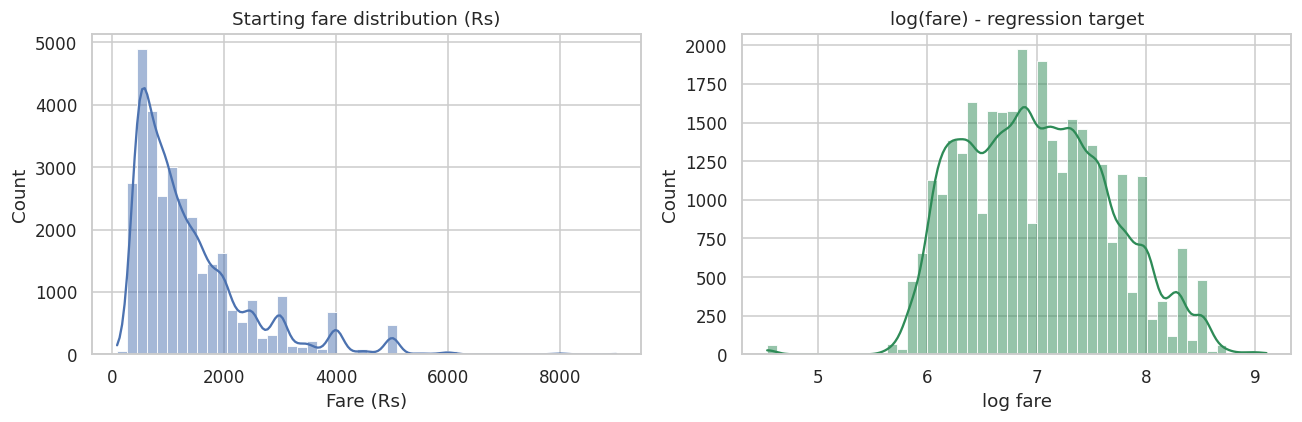

Skewness: raw = 1.91, log = 0.21


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["fare"], bins=50, ax=ax[0], kde=True)
ax[0].set_title("Starting fare distribution (Rs)"); ax[0].set_xlabel("Fare (Rs)")
sns.histplot(np.log(df["fare"]), bins=50, ax=ax[1], kde=True, color="seagreen")
ax[1].set_title("log(fare) - regression target"); ax[1].set_xlabel("log fare")
plt.tight_layout(); plt.savefig("assets/figures/fig1_fare_distribution.png", bbox_inches="tight"); plt.show()
print(f"Skewness: raw = {df['fare'].skew():.2f}, log = {np.log(df['fare']).skew():.2f}")

### 5.1 Fare versus booking window - comparing the *same* bus service

Comparing raw averages across departure dates mixes different buses (fewer operators have opened sales
60 days out). To isolate timing, each listing's fare is indexed to the **median fare of the same bus
service across all 13 departure dates** (index 100 = that bus's usual fare). This holds route, operator,
bus type and departure time fixed. Medians are used because a few services post very high placeholder
fares for far-off dates, which drag means upward.

Services observed on >=5 dates: 3,073 (30,391 listings)


,travel_day,festival,n,median_all,mean_all,occupancy,median_private,median_govt
days_to_departure,,,,,,,,
1,Saturday,0,2568,84.5,80.7,0.3,80.0,100.0
2,Sunday,0,2755,92.3,86.0,0.2,88.1,100.0
3,Monday,0,2799,90.5,83.7,0.2,84.7,100.0
4,Tuesday,0,2786,94.1,85.9,0.2,88.9,100.0
5,Wednesday,0,2841,100.0,99.5,0.2,100.0,100.0
6,Thursday,1,2809,118.2,133.6,0.2,128.5,100.0
7,Friday,1,2868,100.0,118.0,0.2,105.2,100.0
10,Monday,0,2866,100.0,103.3,0.2,100.0,100.0
14,Friday,0,2852,102.4,123.5,0.2,107.9,100.0


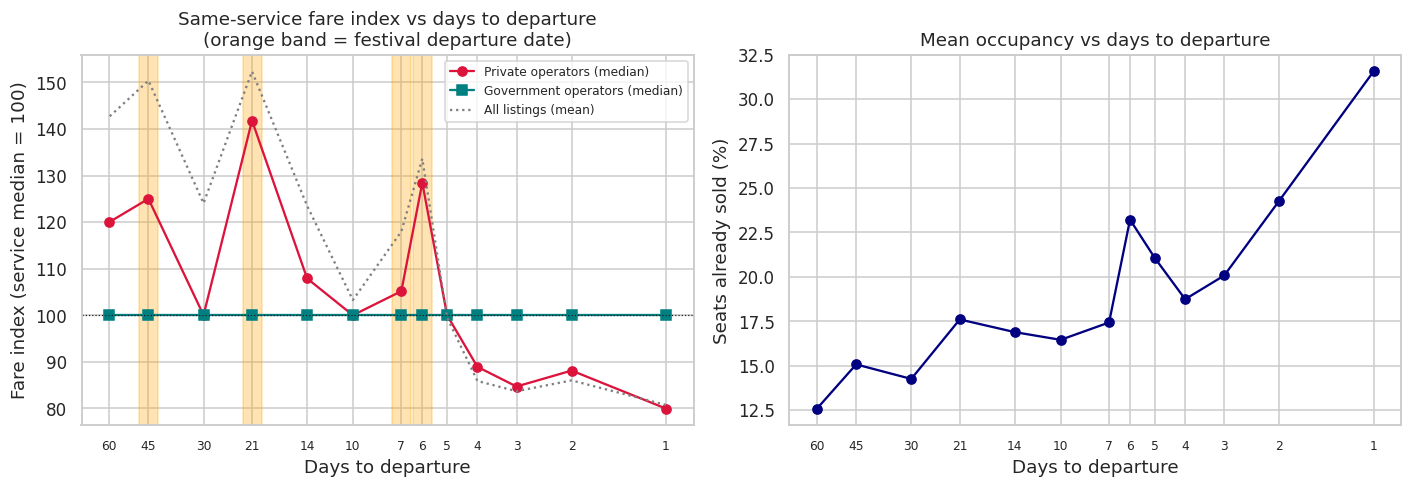

In [7]:
svc_med = df.groupby("service_key")["fare"].transform("median")
svc_n   = df.groupby("service_key")["fare"].transform("size")
df["svc_index"] = 100 * df["fare"] / svc_med
panel = df[svc_n >= 5].copy()          # services observed on at least 5 of the 13 dates
print(f"Services observed on >=5 dates: {panel['service_key'].nunique():,} ({len(panel):,} listings)")

curve = panel.groupby("days_to_departure").agg(
    travel_day=("day_of_week", "first"), festival=("is_festival", "max"), n=("svc_index", "size"),
    median_all=("svc_index", "median"), mean_all=("svc_index", "mean"), occupancy=("occupancy", "mean"))
own = panel.pivot_table(index="days_to_departure", columns="is_govt", values="svc_index", aggfunc="median")
curve["median_private"] = own[0]; curve["median_govt"] = own[1]
display(curve.round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
x = curve.index
ax[0].plot(x, curve["median_private"], "o-", color="crimson", label="Private operators (median)")
ax[0].plot(x, curve["median_govt"], "s-", color="teal", label="Government operators (median)")
ax[0].plot(x, curve["mean_all"], ":", color="grey", label="All listings (mean)")
for d in curve.index[curve["festival"] == 1]:
    ax[0].axvspan(d * 0.93, d * 1.07, color="orange", alpha=0.3)
ax[0].axhline(100, color="k", lw=0.8, ls=":")
ax[0].set_xscale("log"); ax[0].invert_xaxis()
ax[0].set_xticks(list(x)); ax[0].set_xticklabels(list(x), fontsize=8); ax[0].minorticks_off()
ax[0].set_title("Same-service fare index vs days to departure\n(orange band = festival departure date)")
ax[0].set_xlabel("Days to departure"); ax[0].set_ylabel("Fare index (service median = 100)")
ax[0].legend(fontsize=8)
ax[1].plot(x, 100 * curve["occupancy"], "o-", color="navy")
ax[1].set_xscale("log"); ax[1].invert_xaxis()
ax[1].set_xticks(list(x)); ax[1].set_xticklabels(list(x), fontsize=8); ax[1].minorticks_off()
ax[1].set_title("Mean occupancy vs days to departure"); ax[1].set_xlabel("Days to departure")
ax[1].set_ylabel("Seats already sold (%)")
plt.tight_layout(); plt.savefig("assets/figures/fig2_fare_vs_dtd.png", bbox_inches="tight"); plt.show()

**Controlling for travel day.** Near and far departure dates fall on different weekdays. Pairs of dates
with the *same* weekday isolate the booking-window effect (private operators, same services).

In [8]:
priv = panel[panel["is_govt"] == 0]
pairs = [("Monday", 3, 10), ("Tuesday", 4, 60), ("Sunday", 2, 30)]
rows = []
for dow_, near_d, far_d in pairs:
    a = priv[priv["days_to_departure"] == near_d].set_index("service_key")["svc_index"]
    b = priv[priv["days_to_departure"] == far_d].set_index("service_key")["svc_index"]
    common = a.index.intersection(b.index)
    diff = 100 * (a[common] / b[common] - 1)
    rows.append({"travel day": dow_, "near (days out)": near_d, "far (days out)": far_d,
                 "services in both": len(common), "median near vs far %": diff.median(),
                 "share cheaper near %": 100 * (diff < 0).mean(), "share dearer near %": 100 * (diff > 0).mean()})
dow_pairs = pd.DataFrame(rows).round(1)
display(dow_pairs)

nf = panel[panel["is_festival"] == 0]
w = pd.cut(nf["days_to_departure"], [0, 4, 60], labels=["1-4 days", "5-60 days"])
tab = nf.assign(window=w).pivot_table(index="is_govt", columns="window", values="svc_index", aggfunc="median")
tab.index = ["Private", "Government"]
display(tab.round(1))
p_near, p_far = tab.loc["Private", "1-4 days"], tab.loc["Private", "5-60 days"]
print(f"Private, non-festival: median index 1-4 days = {p_near:.1f} vs 5-60 days = {p_far:.1f}"
      f"  -> last-minute discount {100*(1-p_near/p_far):.1f}%")
fest = panel[panel["is_govt"] == 0].groupby("is_festival")["svc_index"].median()
print(f"Private, festival vs non-festival departures: median index {fest[1]:.1f} vs {fest[0]:.1f}"
      f"  -> festival premium {100*(fest[1]/fest[0]-1):.1f}%")

,travel day,near (days out),far (days out),services in both,median near vs far %,share cheaper near %,share dearer near %
0,Monday,3,10,2287,-9.1,56.1,7.9
1,Tuesday,4,60,300,-48.6,72.3,3.7
2,Sunday,2,30,1110,-25.0,69.7,7.4


window,1-4 days,5-60 days
Private,85.7,100.0
Government,100.0,100.0


Private, non-festival: median index 1-4 days = 85.7 vs 5-60 days = 100.0  -> last-minute discount 14.3%
Private, festival vs non-festival departures: median index 120.0 vs 100.0  -> festival premium 20.0%


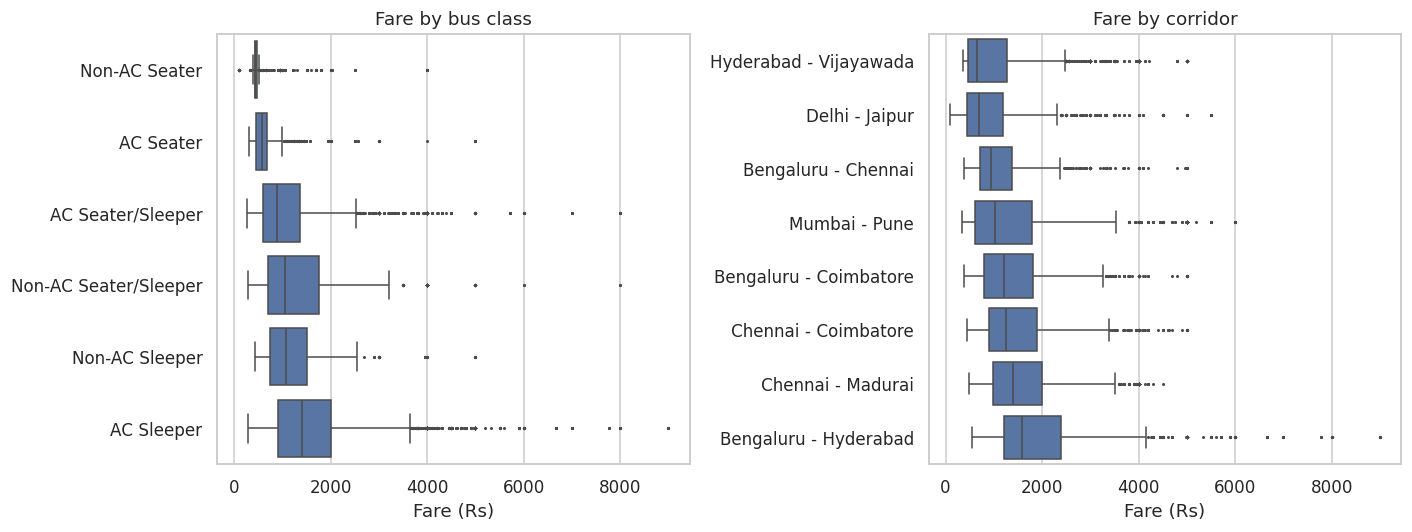

is_govt
Private       1199.0
Government     533.0
Name: fare, dtype: float64


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
order = df.groupby("bus_class")["fare"].median().sort_values().index
sns.boxplot(data=df, x="fare", y="bus_class", order=order, ax=ax[0], fliersize=1)
ax[0].set_title("Fare by bus class"); ax[0].set_xlabel("Fare (Rs)"); ax[0].set_ylabel("")
order = df.groupby("route")["fare"].median().sort_values().index
sns.boxplot(data=df, x="fare", y="route", order=order, ax=ax[1], fliersize=1)
ax[1].set_title("Fare by corridor"); ax[1].set_xlabel("Fare (Rs)"); ax[1].set_ylabel("")
plt.tight_layout(); plt.savefig("assets/figures/fig3_fare_by_class_route.png", bbox_inches="tight"); plt.show()
print(df.groupby("is_govt")["fare"].median().rename({0:"Private",1:"Government"}))

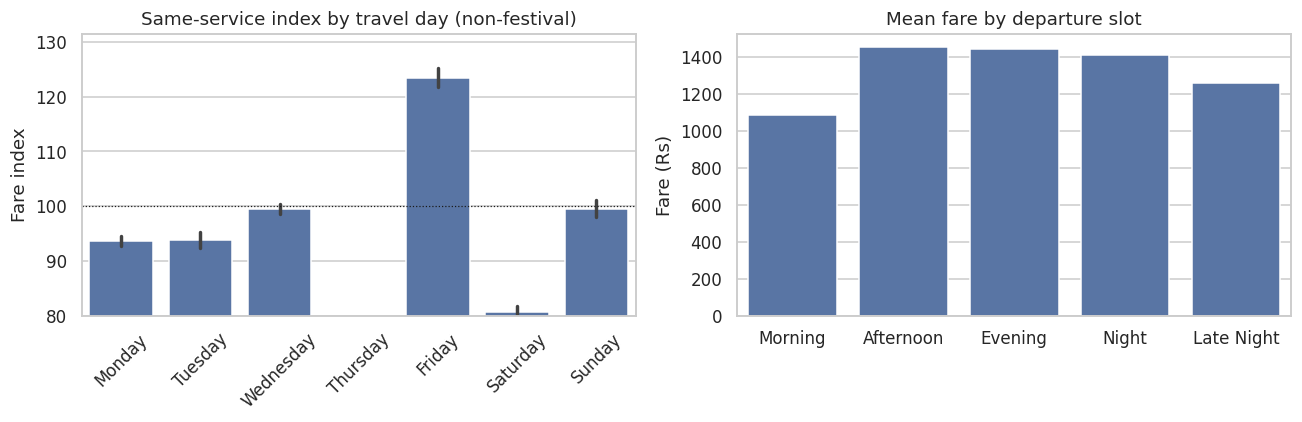

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
dow = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.barplot(data=panel[panel["is_festival"] == 0], x="day_of_week", y="svc_index",
            order=[d for d in dow if d in set(panel["day_of_week"])], ax=ax[0], errorbar=("ci", 95))
ax[0].axhline(100, color="k", lw=0.8, ls=":"); ax[0].set_ylim(80, None)
ax[0].tick_params(axis="x", rotation=45); ax[0].set_title("Same-service index by travel day (non-festival)")
ax[0].set_xlabel(""); ax[0].set_ylabel("Fare index")
slot_order = ["Morning","Afternoon","Evening","Night","Late Night"]
sns.barplot(data=df, x="dep_slot", y="fare", order=[s for s in slot_order if s in set(df["dep_slot"])],
            ax=ax[1], errorbar=None)
ax[1].set_title("Mean fare by departure slot"); ax[1].set_xlabel(""); ax[1].set_ylabel("Fare (Rs)")
plt.tight_layout(); plt.savefig("assets/figures/fig4_dow_slot.png", bbox_inches="tight"); plt.show()

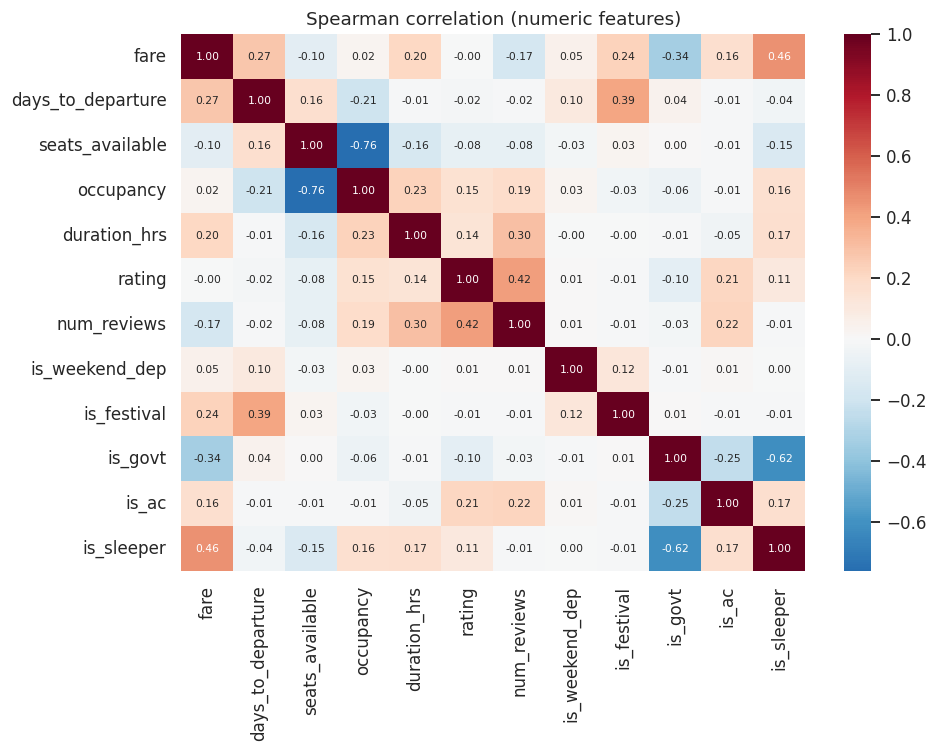

In [11]:
numc = df[["fare","days_to_departure","seats_available","occupancy","duration_hrs","rating",
           "num_reviews","is_weekend_dep","is_festival","is_govt","is_ac","is_sleeper"]]
plt.figure(figsize=(9, 7))
sns.heatmap(numc.corr(method="spearman"), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            annot_kws={"size": 7})
plt.title("Spearman correlation (numeric features)")
plt.tight_layout(); plt.savefig("assets/figures/fig5_correlation.png", bbox_inches="tight"); plt.show()

## 6. Model 1 - Fare Regression

Methods from the Business Analytics syllabus: **multiple linear regression** (interpretable baseline)
and **ensemble tree regression** (Random Forest, Gradient Boosting) to capture the non-linear booking
curve and interactions (e.g. bus class x route). Target = log(fare) because fares are right-skewed.
Evaluation: 80/20 random split plus 5-fold cross-validation on the training part; R2 on log fare, MAE,
RMSE and MAPE in rupees on the test set.

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, accuracy_score,
                             f1_score, roc_auc_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

FEATS_NUM = ["days_to_departure","occupancy","seats_available","duration_hrs","rating","num_reviews",
             "is_weekend_dep","is_festival","is_govt"]
FEATS_CAT = ["route","operator_grp","bus_class","dep_slot","day_of_week"]
X = df[FEATS_NUM + FEATS_CAT]
y = np.log(df["fare"])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED)
prep = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATS_CAT)],
                         remainder="passthrough")

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06, random_state=SEED),
}
reg_rows, fitted = [], {}
kf = KFold(5, shuffle=True, random_state=SEED)
for name, m in models.items():
    pipe = Pipeline([("prep", prep), ("m", m)]).fit(X_tr, y_tr)
    fitted[name] = pipe
    cv = cross_val_score(Pipeline([("prep", prep), ("m", m)]), X_tr, y_tr, cv=kf, scoring="r2")
    pl = pipe.predict(X_te); p, a = np.exp(pl), np.exp(y_te)
    reg_rows.append({"Model": name, "CV R2 (log)": cv.mean(), "Test R2 (log)": r2_score(y_te, pl),
                     "MAE (Rs)": mean_absolute_error(a, p), "RMSE (Rs)": math.sqrt(mean_squared_error(a, p)),
                     "MAPE (%)": 100 * np.mean(np.abs(a - p) / a)})
reg_table = pd.DataFrame(reg_rows).set_index("Model").round(3)
reg_table

,CV R2 (log),Test R2 (log),MAE (Rs),RMSE (Rs),MAPE (%)
Model,,,,,
Linear Regression,0.575,0.575,474.541,786.381,34.566
Random Forest,0.801,0.830,282.206,517.264,18.752
Gradient Boosting,0.780,0.789,330.794,578.771,22.474


Best regressor: Random Forest


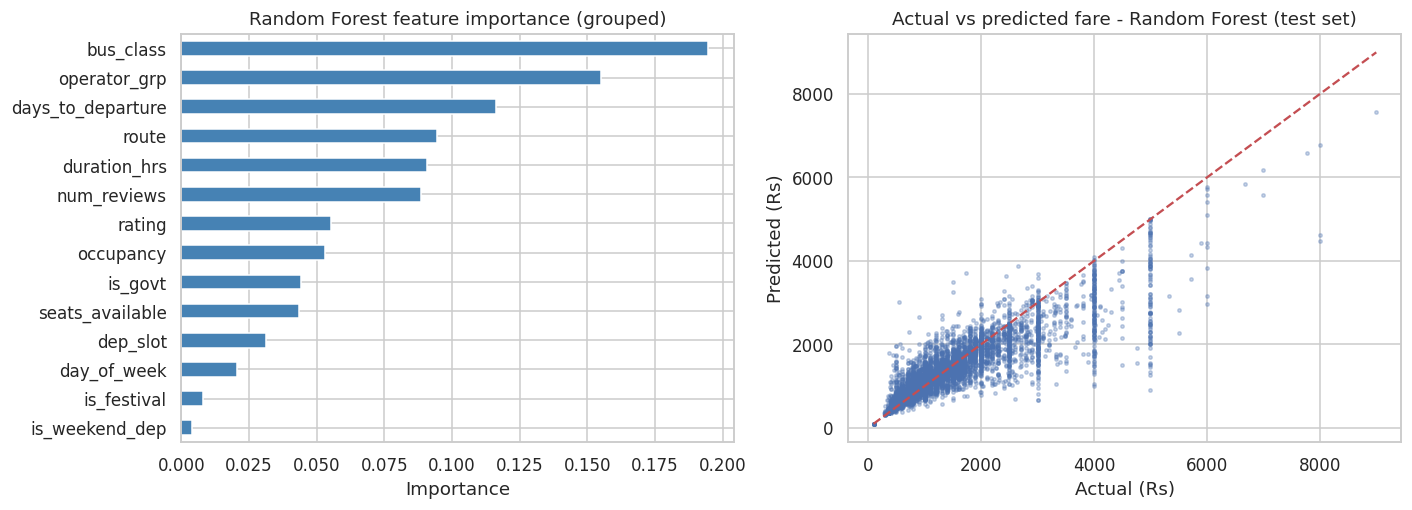

bus_class            0.195
operator_grp         0.155
days_to_departure    0.116
route                0.094
duration_hrs         0.091
num_reviews          0.088
rating               0.055
occupancy            0.053
is_govt              0.044
seats_available      0.043
dep_slot             0.031
day_of_week          0.021
is_festival          0.008
is_weekend_dep       0.004

Linear model - % fare effect:
  days_to_departure  +1.10%
  occupancy          -18.85%
  is_festival        +6.51%
  is_weekend_dep     -2.93%
  is_govt            -23.21%


In [13]:
best_reg = reg_table["Test R2 (log)"].idxmax()
print("Best regressor:", best_reg)
rf = fitted["Random Forest"]
names = list(rf["prep"].named_transformers_["cat"].get_feature_names_out(FEATS_CAT)) + FEATS_NUM
imp = pd.Series(rf["m"].feature_importances_, index=names)
grouped = {c: imp[[n for n in names if n.startswith(c + "_")]].sum() for c in FEATS_CAT}
grouped.update({c: imp[c] for c in FEATS_NUM})
gi = pd.Series(grouped).sort_values()

pb = np.exp(fitted[best_reg].predict(X_te)); ab = np.exp(y_te)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
gi.plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("Random Forest feature importance (grouped)"); ax[0].set_xlabel("Importance")
ax[1].scatter(ab, pb, s=5, alpha=0.3)
lims = [ab.min(), ab.max()]; ax[1].plot(lims, lims, "r--")
ax[1].set_title(f"Actual vs predicted fare - {best_reg} (test set)")
ax[1].set_xlabel("Actual (Rs)"); ax[1].set_ylabel("Predicted (Rs)")
plt.tight_layout(); plt.savefig("assets/figures/fig6_regression.png", bbox_inches="tight"); plt.show()
print(gi.sort_values(ascending=False).round(3).to_string())

# Interpretable view: linear-model coefficients for the timing variables (log points ~ % effect)
lr = fitted["Linear Regression"]
coef = pd.Series(lr["m"].coef_, index=names)
print("\nLinear model - % fare effect:")
for c in ["days_to_departure","occupancy","is_festival","is_weekend_dep","is_govt"]:
    print(f"  {c:<18} {100*(np.exp(coef[c])-1):+.2f}%")

## 7. Model 2 - "Book Now" vs "Wait" Classification

**Label (empirical, not model-generated).** Many services run daily and were observed on several
departure dates. For each such service the *near-departure fare* is its mean fare on dates 1-3 days
out. A listing 4 or more days out is labelled **Book Now** if its fare is at least 5% below that
service's near-departure fare, otherwise **Wait** (buying now saves little or nothing versus buying
at the last moment). The 5% band ignores trivial differences.

Festival departures are excluded from this model: the 1-3-day reference dates are all ordinary days,
so comparing a festival quote against them would not describe a real "wait" option. Festival timing is
handled by the festival-premium analysis in sections 5.1 and 8.

**Classifier.** Logistic Regression and Random Forest predict the label from listing attributes available
at search time - what a platform "fare guidance" badge would compute. Evaluation on a stratified 80/20
split against a majority-class baseline, reporting accuracy, F1 and ROC-AUC.

Labelled listings: 13,010 across 3,040 services
book_now
Wait        0.884
Book Now    0.116
Name: proportion, dtype: float64


,Accuracy,F1 (Book Now),ROC-AUC
Model,,,
Majority-class baseline,0.884,NaN,0.500
Logistic Regression,0.733,0.407,0.844
Random Forest,0.864,0.546,0.893



Random Forest - test set

              precision    recall  f1-score   support

        Wait       0.96      0.88      0.92      2300
    Book Now       0.45      0.71      0.55       302

    accuracy                           0.86      2602
   macro avg       0.70      0.80      0.73      2602
weighted avg       0.90      0.86      0.88      2602



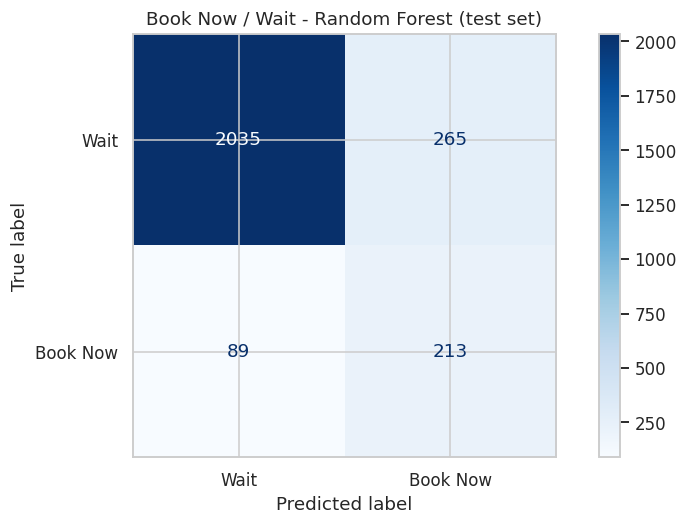

In [14]:
near = df[df["days_to_departure"] <= 3].groupby("service_key")["fare"].mean().rename("near_fare")
cl = df[(df["days_to_departure"] >= 4) & (df["is_festival"] == 0)].merge(near, left_on="service_key", right_index=True)
cl["book_now"] = (cl["fare"] <= 0.95 * cl["near_fare"]).astype(int)
cl["saving_pct"] = 100 * (cl["near_fare"] - cl["fare"]) / cl["near_fare"]
print(f"Labelled listings: {len(cl):,} across {cl['service_key'].nunique():,} services")
print(cl["book_now"].value_counts(normalize=True).rename({1: "Book Now", 0: "Wait"}).round(3))

Xc, yc = cl[FEATS_NUM + FEATS_CAT], cl["book_now"]
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=SEED, stratify=yc)
base_acc = max(yc_te.mean(), 1 - yc_te.mean())

prep_c = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATS_CAT),
                            ("num", "passthrough", FEATS_NUM)])
from sklearn.preprocessing import StandardScaler
prep_lr = ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), FEATS_CAT),
                             ("num", StandardScaler(), FEATS_NUM)])
clfs = {
    "Logistic Regression": Pipeline([("prep", prep_lr), ("m", LogisticRegression(max_iter=3000, class_weight="balanced"))]),
    "Random Forest": Pipeline([("prep", prep_c), ("m", RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                                                   class_weight="balanced", random_state=SEED, n_jobs=-1))]),
}
cls_rows = [{"Model": "Majority-class baseline", "Accuracy": base_acc, "F1 (Book Now)": np.nan, "ROC-AUC": 0.5}]
for name, pipe in clfs.items():
    pipe.fit(Xc_tr, yc_tr)
    p = pipe.predict(Xc_te); pr = pipe.predict_proba(Xc_te)[:, 1]
    cls_rows.append({"Model": name, "Accuracy": accuracy_score(yc_te, p), "F1 (Book Now)": f1_score(yc_te, p),
                     "ROC-AUC": roc_auc_score(yc_te, pr)})
cls_table = pd.DataFrame(cls_rows).set_index("Model").round(3)
display(cls_table)

best_clf = cls_table.drop("Majority-class baseline")["ROC-AUC"].idxmax()
p = clfs[best_clf].predict(Xc_te)
print(f"\n{best_clf} - test set\n")
print(classification_report(yc_te, p, target_names=["Wait", "Book Now"]))
ConfusionMatrixDisplay(confusion_matrix(yc_te, p), display_labels=["Wait", "Book Now"]).plot(cmap="Blues")
plt.title(f"Book Now / Wait - {best_clf} (test set)")
plt.savefig("assets/figures/fig7_confusion.png", bbox_inches="tight"); plt.show()

## 8. Business Insight - Escalation by Operator and Corridor, and the Value of Timing

Operators with >=30 listings in both windows: 56
  cut fares >5% in last 4 days : 36
  roughly flat (+/-5%)         : 20
  raise fares >5%              : 0


,median index 1-4 days,median index 5-60 days,listings,last-minute change %
operator,,,,
N.T Ashoka,60.4,119.8,93.0,-49.6
IntrCity SmartBus,55.2,100.3,630.0,-44.9
National Travels CHN,58.3,100.0,185.0,-41.7
Dolphin Travel House,67.5,113.9,175.0,-40.7
V Kaveri Travels,62.4,100.0,90.0,-37.6
KBS Luxury Bus,64.5,100.0,295.0,-35.5
YOLOBUS PRIVATE LIMITED,65.8,100.0,77.0,-34.2
Shyamoli Paribahan Pvt Ltd,68.0,101.9,113.0,-33.2
SHREE GANESH TOURS AND TRAVELS,100.0,100.0,66.0,0.0


window,1-4,5-60,last-minute change %,festival premium %
route,,,,
Bengaluru - Chennai,78.9,100.0,-21.1,26.7
Chennai - Coimbatore,79.0,100.0,-21.0,59.8
Bengaluru - Hyderabad,81.4,100.0,-18.6,20.2
Hyderabad - Vijayawada,81.6,100.0,-18.4,11.2
Bengaluru - Coimbatore,82.5,100.0,-17.5,66.4
Mumbai - Pune,85.7,100.0,-14.3,0.0
Chennai - Madurai,90.0,100.0,-10.0,31.1
Delhi - Jaipur,100.0,100.0,0.0,0.0


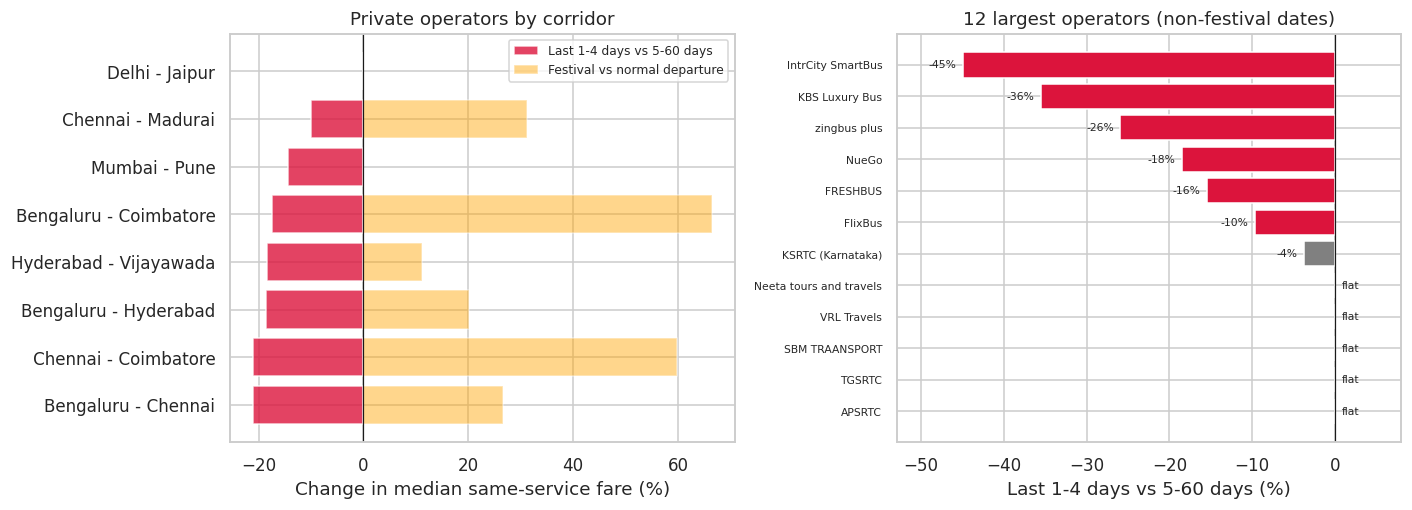

In [15]:
nfp = panel[(panel["is_festival"] == 0)].copy()
nfp["window"] = pd.cut(nfp["days_to_departure"], [0, 4, 60], labels=["1-4", "5-60"])

ops = (nfp.groupby(["operator", "window"])["svc_index"].agg(["median", "size"]).unstack())
ops = ops[(ops[("size", "1-4")] >= 30) & (ops[("size", "5-60")] >= 30)]
op_tab = pd.DataFrame({"median index 1-4 days": ops[("median", "1-4")],
                       "median index 5-60 days": ops[("median", "5-60")],
                       "listings": ops[("size", "1-4")] + ops[("size", "5-60")]})
op_tab["last-minute change %"] = 100 * (op_tab["median index 1-4 days"] / op_tab["median index 5-60 days"] - 1)
op_tab = op_tab.sort_values("last-minute change %").round(1)
print(f"Operators with >=30 listings in both windows: {len(op_tab)}")
print(f"  cut fares >5% in last 4 days : {(op_tab['last-minute change %'] < -5).sum()}")
print(f"  roughly flat (+/-5%)         : {op_tab['last-minute change %'].between(-5, 5).sum()}")
print(f"  raise fares >5%              : {(op_tab['last-minute change %'] > 5).sum()}")
display(pd.concat([op_tab.head(8), op_tab.tail(6)]))

rt = (nfp[nfp["is_govt"] == 0].groupby(["route", "window"])["svc_index"].median().unstack())
rt["last-minute change %"] = 100 * (rt["1-4"] / rt["5-60"] - 1)
fr = panel[panel["is_govt"] == 0].groupby(["route", "is_festival"])["svc_index"].median().unstack()
rt["festival premium %"] = 100 * (fr[1] / fr[0] - 1)
rt = rt.sort_values("last-minute change %").round(1)
display(rt)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
r2 = rt.sort_values("last-minute change %")
ax[0].barh(r2.index, r2["last-minute change %"], color="crimson", alpha=0.8, label="Last 1-4 days vs 5-60 days")
ax[0].barh(r2.index, r2["festival premium %"], color="orange", alpha=0.45, label="Festival vs normal departure")
ax[0].axvline(0, color="k", lw=0.8); ax[0].legend(fontsize=8)
ax[0].set_xlabel("Change in median same-service fare (%)"); ax[0].set_title("Private operators by corridor")
cl_ops = op_tab.sort_values("listings", ascending=False).head(12).sort_values("last-minute change %", ascending=False)
vals = cl_ops["last-minute change %"]
ax[1].barh(cl_ops.index, vals, color=["crimson" if v < -5 else "grey" for v in vals])
for i, v in enumerate(vals):
    ax[1].text(v - 0.8 if v < 0 else 0.8, i, f"{v:.0f}%" if abs(v) > 0.5 else "flat",
               va="center", ha="right" if v < 0 else "left", fontsize=7)
ax[1].axvline(0, color="k", lw=0.8); ax[1].tick_params(axis="y", labelsize=7)
ax[1].set_xlim(min(vals.min() - 8, -10), 8)
ax[1].set_xlabel("Last 1-4 days vs 5-60 days (%)"); ax[1].set_title("12 largest operators (non-festival dates)")
plt.tight_layout(); plt.savefig("assets/figures/fig8_operator_route.png", bbox_inches="tight"); plt.show()

In [16]:
bn = cl[cl["book_now"] == 1]
print(f"Book Now share of labelled listings: {100*len(bn)/len(cl):.1f}%")
print(f"When Book Now: median saving vs same service's near-departure fare = {bn['saving_pct'].median():.1f}% "
      f"(Rs {(bn['near_fare']-bn['fare']).median():,.0f})")
wt = cl[cl["book_now"] == 0]
print(f"When Wait: median extra cost of booking now instead of 1-3 days out = {(-wt['saving_pct']).median():.1f}% "
      f"(Rs {(wt['fare']-wt['near_fare']).median():,.0f})")
print("\nBook Now share by segment (%):")
seg = pd.concat({
    "operator type": cl.groupby("is_govt")["book_now"].mean().rename({0: "private", 1: "government"}),
    "bus class": cl.groupby("bus_class")["book_now"].mean(),
})
display((100 * seg).round(1).to_frame("Book Now %"))
by_route = cl.groupby("route").agg(book_now_pct=("book_now", "mean"),
                                   median_extra_cost_if_booked_now_pct=("saving_pct", lambda s: -s.median()))
by_route["book_now_pct"] *= 100
display(by_route.round(1).sort_values("book_now_pct", ascending=False))

Book Now share of labelled listings: 11.6%
When Book Now: median saving vs same service's near-departure fare = 14.3% (Rs 120)
When Wait: median extra cost of booking now instead of 1-3 days out = 14.0% (Rs 105)

Book Now share by segment (%):


Book Now %
operator type private                      13.2
              government                    1.2
bus class     AC Seater                     7.2
              AC Seater/Sleeper            15.9
              AC Sleeper                   12.0
              Non-AC Seater                 0.1
              Non-AC Seater/Sleeper        11.2
              Non-AC Sleeper               11.6

,book_now_pct,median_extra_cost_if_booked_now_pct
route,,
Bengaluru - Chennai,25.5,11.1
Chennai - Madurai,19.7,7.6
Delhi - Jaipur,17.8,-0.0
Chennai - Coimbatore,12.7,22.4
Bengaluru - Hyderabad,11.9,12.2
Bengaluru - Coimbatore,9.3,18.2
Mumbai - Pune,8.4,14.3
Hyderabad - Vijayawada,2.5,-0.0


## 9. Conclusions

The conclusions, recommendations and limitations drawn from these outputs are written up in
`Case_Study_Report.pdf` (sections 6-7). Key numbers are printed in the cells above.

---
*All data was collected from publicly accessible redBus listing pages on 25 Sep 2026 for academic use only;
no personal data was collected.*